# Sound Waves in BECs

Here, we try to simulate the results from [this paper](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.79.553), on the propagation of sound waves in a condensate. We are going to create a condensate in the ground state of an elongated square trap, then perturb it at its center and look at the propagation of the perturbation using a Groos-Pitaevskii simulation.

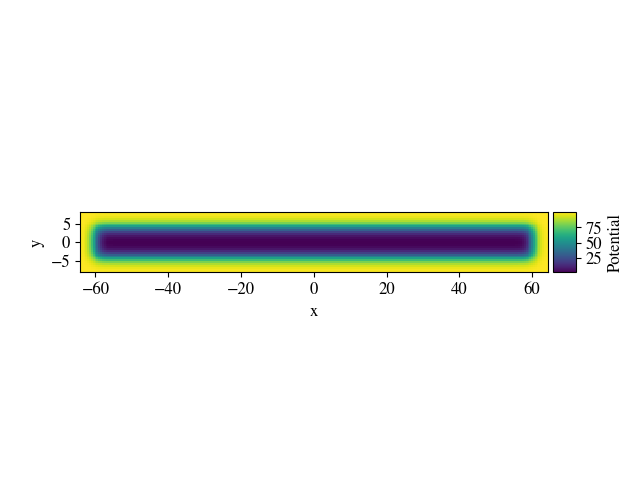

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import create_parameter
from BECs.groundstate import GroundStateSSFM
from BECs.potentialT import PotentialT
from BECs.ssfm import SSFM

%matplotlib widget

lx, ly = 128,16
nres = 5

trap = PotentialT(
    [[lx,0],[0,ly]],
    (2**(nres+3), 2**(nres)),
    v0 = 100
)

omegax, omegay = 0.005, 80

trap.rectangle(
    center = (0,0),
    dims = [120, 8]
)

trap.smooth(3,3) # We smooth the potential as spectral methods usually do not like sharp features

fig, ax = trap.plot()

The local speed of sound in a BEC at 0K is given by [Bogoliubov](https://www.ufn.ru/dates/pdf/j_phys_ussr/j_phys_ussr_1947_11_1/3_bogolubov_j_phys_ussr_1947_11_1_23.pdf)
$$c(r) = \sqrt{n(r) U / m}$$
with $n(r)$ the fluid density, $U$ the repulsive interaction and $m$ the mass of the atoms. We propose to test this relation numerically by generating sound waves with a short pulse in the middle of the condensate and tracking their speed of propagation for multiple values of U.

To do so, we first have to compute the ground state of the weel, which we do using the `GroundStateSSFM` solver. We will work with $\hbar = m = 1$

In [ ]:
# Computing the ground state of the trap for 1000 atoms and interactions between 20 and 20
u = create_parameter('U', np.linspace(1, 10, 10))
population = 1000


grd = GroundStateSSFM(
    trap, u
)

energies, psi0 = grd.solve(
    1000, tol_adapt = 1e-12, tol_stop = 1e-13, parallelize=True, n_cores=10
)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:   12.6s remaining:   29.4s
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:   12.8s remaining:    8.5s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   14.1s finished


Reshaping and storing


100%|██████████| 10/10 [00:00<00:00, 1490.83it/s]


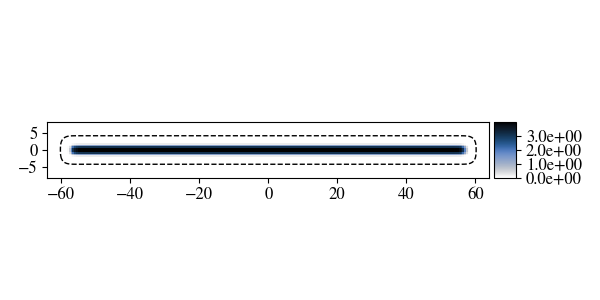

In [3]:

from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector
%matplotlib widget

fig, axes = plot_eigenvector(
    [[abs(psi0)**2]],
    [[trap]],
    [['amplitude']]
)

We can see that we are well and truly into the Thomas-Fermi limit, as the BEC groundstate density closely matches the shape of the potential.

Now, we will perturb this ground state by pulsing a short gaussian potential increase in the middle of the condensate. Experimentally speaking, this small pulse was realized using a laser pulse.

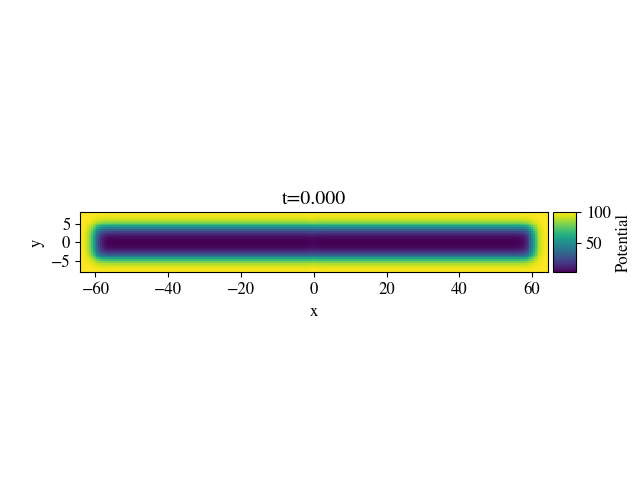

In [ ]:
from BECs.ufuncs import gaussian2D

ti, tf = 0, 10 # Initial and final time of the simulation

sigma_spatial = 1
amp = 1

sigma_t = 0.15
t0 = 0.3

trap.add_shape("gaussianbeam", gaussian2D(trap.x, trap.y, 0, 0, sigma_spatial, 50, amp))
trap.gaussian("pulse", t0, sigma_t, norm = 'peak')

trap.add_term("gaussianbeam * pulse")

fig, ax = trap.plot_t(ti,tf,200, vmax = 50)

In [ ]:
%reload_ext autoreload
%autoreload 2


t_samples = create_parameter('t', np.linspace(ti,tf, 200))

solv = SSFM(
    trap, psi0, u
)

psi = solv.solve(
    t_init=ti,
    t_final=tf,
    t_samples=t_samples,
    parallelize=True,
    n_cores=10,
    verbose=True,
    tol = 1e-8
)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   1 tasks      | elapsed:   52.6s
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:   53.4s remaining:  3.6min
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  1.3min remaining:  2.9min
[Parallel(n_jobs=10)]: Done   4 out of  10 | elapsed:  1.4min remaining:  2.1min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  1.5min remaining:  1.5min
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:  1.6min remaining:  1.1min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  1.7min remaining:   43.3s
[Parallel(n_jobs=10)]: Done   8 out of  10 | elapsed:  1.7min remaining:   25.4s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  1.8min finished


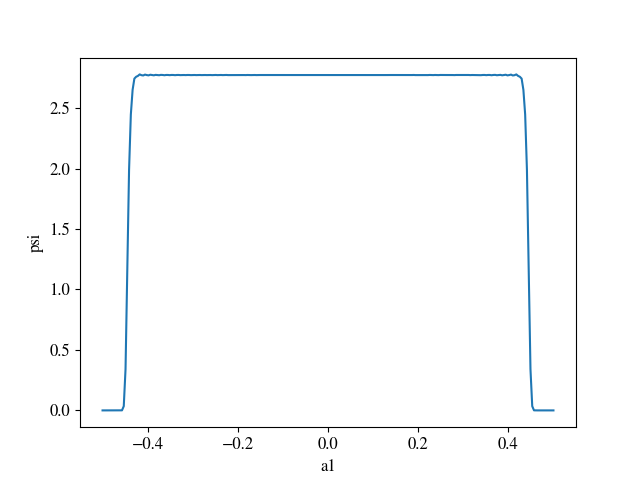

In [36]:
fig, ax = plot_cuts(
    (abs(psi.sel(a2 = slice(-0.1, 0.1)))**2).mean('a2'),
    'a1',
    groupby=(),
)

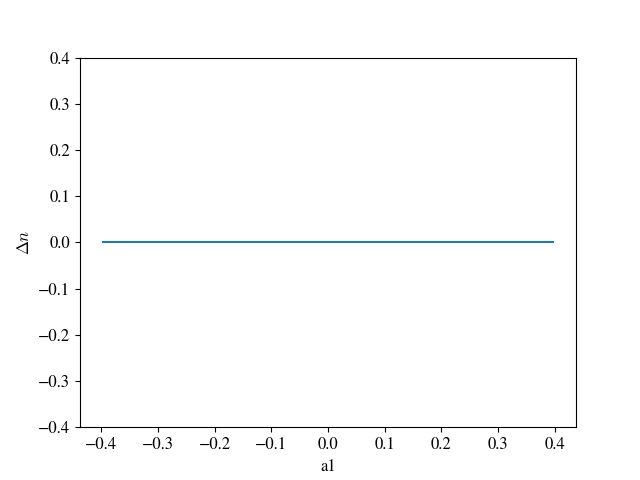

In [40]:
psi_crop = psi.sel(a1 = slice(-0.4, 0.4), a2 = slice(-0.2, 0.2)).mean('a2')
delta_density = abs(psi_crop)**2 - abs(psi_crop.sel(t = 0))**2

fig, ax = plot_cuts(
    delta_density.rename(r"$\Delta n$"),
    'a1',
    groupby=[],
    ymin = -0.4,
    ymax = 0.4
)

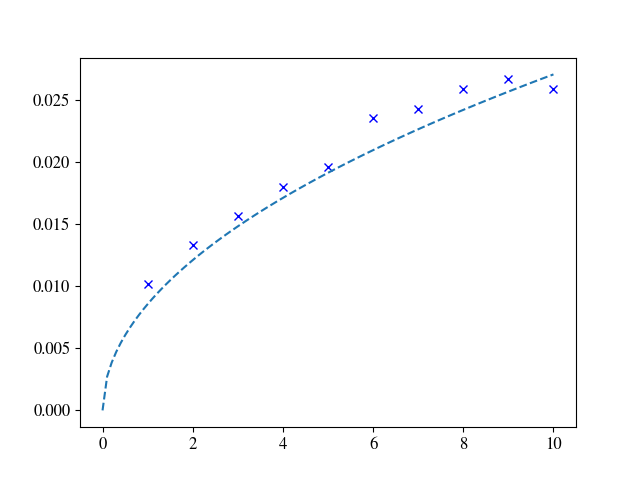

In [39]:
delta_density_positive = abs(delta_density.sel(a1 = slice(0, 0.4)))
t1 = 3
t2 = 8
where_max_1 = delta_density_positive.sel(t = t1, method = 'nearest').argmax('a1')
where_max_2 = delta_density_positive.sel(t = t2, method = 'nearest').argmax('a1')
speed = (delta_density_positive.a1.isel(a1 = where_max_2) - delta_density_positive.a1.isel(a1 = where_max_1))/(t2-t1)

U_th = np.linspace(0, 10, 100)
speed_th = ((abs(psi_crop)**2).mean().data / 1.5e4 * U_th)**0.5
# print(delta_density.mean())
plt.close('all')
plt.plot(speed.U, speed, 'x', c = 'blue')
plt.plot(U_th, speed_th, linestyle = 'dashed')
plt.show()